In [488]:
import xgboost as xgb
from tensorflow.python.ops.metrics_impl import mean_absolute_error

import model_XGBoost as xgb_model

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.relativedelta import relativedelta
import datetime as dt
import holidays
holidays_de= holidays.Germany()

from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import scipy.stats as stats

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

In [489]:
df_all = pd.read_csv('../../data_cleaned/merged/02_4_clean_data.csv')
df_all.head()

,date,year,month,day,dayofyear,hour,dayofweek,price,period_start_utc,period_end_utc,...,res_sum_da,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
0,2019-01-01,2019,1,1,1,0,1,10.07,2019-01-01 00:00:00+00:00,2019-01-01 01:00:00+00:00,...,25669.0050,0.0,1.0,0.000000,1.000000,0.781831,0.62349,1,holiday,22.28
1,2019-01-01,2019,1,1,1,1,1,-4.08,2019-01-01 01:00:00+00:00,2019-01-01 02:00:00+00:00,...,27384.1025,0.0,1.0,0.258819,0.965926,0.781831,0.62349,1,holiday,22.28
2,2019-01-01,2019,1,1,1,2,1,-9.91,2019-01-01 02:00:00+00:00,2019-01-01 03:00:00+00:00,...,29010.1275,0.0,1.0,0.500000,0.866025,0.781831,0.62349,1,holiday,22.28
3,2019-01-01,2019,1,1,1,3,1,-7.41,2019-01-01 03:00:00+00:00,2019-01-01 04:00:00+00:00,...,30359.5675,0.0,1.0,0.707107,0.707107,0.781831,0.62349,1,holiday,22.28
4,2019-01-01,2019,1,1,1,4,1,-12.55,2019-01-01 04:00:00+00:00,2019-01-01 05:00:00+00:00,...,31409.2100,0.0,1.0,0.866025,0.500000,0.781831,0.62349,1,holiday,22.28


In [490]:
df_years = df_all.query('2019 <= year').copy()
df_years.head()

,date,year,month,day,dayofyear,hour,dayofweek,price,period_start_utc,period_end_utc,...,res_sum_da,dayofyear_sin1,dayofyear_cos1,hour_sin1,hour_cos1,dayofweek_sin1,dayofweek_cos1,is_holiday,day_type,price_gas
0,2019-01-01,2019,1,1,1,0,1,10.07,2019-01-01 00:00:00+00:00,2019-01-01 01:00:00+00:00,...,25669.0050,0.0,1.0,0.000000,1.000000,0.781831,0.62349,1,holiday,22.28
1,2019-01-01,2019,1,1,1,1,1,-4.08,2019-01-01 01:00:00+00:00,2019-01-01 02:00:00+00:00,...,27384.1025,0.0,1.0,0.258819,0.965926,0.781831,0.62349,1,holiday,22.28
2,2019-01-01,2019,1,1,1,2,1,-9.91,2019-01-01 02:00:00+00:00,2019-01-01 03:00:00+00:00,...,29010.1275,0.0,1.0,0.500000,0.866025,0.781831,0.62349,1,holiday,22.28
3,2019-01-01,2019,1,1,1,3,1,-7.41,2019-01-01 03:00:00+00:00,2019-01-01 04:00:00+00:00,...,30359.5675,0.0,1.0,0.707107,0.707107,0.781831,0.62349,1,holiday,22.28
4,2019-01-01,2019,1,1,1,4,1,-12.55,2019-01-01 04:00:00+00:00,2019-01-01 05:00:00+00:00,...,31409.2100,0.0,1.0,0.866025,0.500000,0.781831,0.62349,1,holiday,22.28


In [491]:
df_years = pd.get_dummies(df_years, columns=['year'], drop_first=True)
df_years.head()

,date,month,day,dayofyear,hour,dayofweek,price,period_start_utc,period_end_utc,load_forecast_da,...,dayofweek_cos1,is_holiday,day_type,price_gas,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
0,2019-01-01,1,1,1,0,1,10.07,2019-01-01 00:00:00+00:00,2019-01-01 01:00:00+00:00,41692.5650,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
1,2019-01-01,1,1,1,1,1,-4.08,2019-01-01 01:00:00+00:00,2019-01-01 02:00:00+00:00,40587.2325,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
2,2019-01-01,1,1,1,2,1,-9.91,2019-01-01 02:00:00+00:00,2019-01-01 03:00:00+00:00,40308.2500,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
3,2019-01-01,1,1,1,3,1,-7.41,2019-01-01 03:00:00+00:00,2019-01-01 04:00:00+00:00,40659.5750,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
4,2019-01-01,1,1,1,4,1,-12.55,2019-01-01 04:00:00+00:00,2019-01-01 05:00:00+00:00,40947.7300,...,0.62349,1,holiday,22.28,False,False,False,False,False,False


In [492]:
df_years.drop(columns=['period_end_utc'], inplace=True)

In [493]:
df_years["period_start_utc"] = pd.to_datetime(df_years["period_start_utc"], errors="coerce")
df_years["period_start_utc"] = df_years["period_start_utc"].apply(lambda x: x.replace(tzinfo=None))
df_years["date"] = pd.to_datetime(df_years["date"], errors="coerce")

In [494]:
df_years.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61367 entries, 0 to 61366
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              61367 non-null  datetime64[ns]
 1   month             61367 non-null  int64         
 2   day               61367 non-null  int64         
 3   dayofyear         61367 non-null  int64         
 4   hour              61367 non-null  int64         
 5   dayofweek         61367 non-null  int64         
 6   price             61367 non-null  float64       
 7   period_start_utc  61367 non-null  datetime64[ns]
 8   load_forecast_da  61367 non-null  float64       
 9   off_wind_da       61367 non-null  float64       
 10  on_wind_da        61367 non-null  float64       
 11  solar_da          61367 non-null  float64       
 12  gen_forecast_da   61367 non-null  float64       
 13  res_sum_da        61367 non-null  float64       
 14  dayofyear_sin1    61367 non

In [495]:
df_years.head()

,date,month,day,dayofyear,hour,dayofweek,price,period_start_utc,load_forecast_da,off_wind_da,...,dayofweek_cos1,is_holiday,day_type,price_gas,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025
0,2019-01-01,1,1,1,0,1,10.07,2019-01-01 00:00:00,41692.5650,5042.4425,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
1,2019-01-01,1,1,1,1,1,-4.08,2019-01-01 01:00:00,40587.2325,5028.4175,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
2,2019-01-01,1,1,1,2,1,-9.91,2019-01-01 02:00:00,40308.2500,4977.6500,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
3,2019-01-01,1,1,1,3,1,-7.41,2019-01-01 03:00:00,40659.5750,4907.4000,...,0.62349,1,holiday,22.28,False,False,False,False,False,False
4,2019-01-01,1,1,1,4,1,-12.55,2019-01-01 04:00:00,40947.7300,4882.8400,...,0.62349,1,holiday,22.28,False,False,False,False,False,False


In [496]:
df_years.set_index('period_start_utc', inplace=True)

In [497]:
df_years.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61367 entries, 2019-01-01 00:00:00 to 2025-12-31 22:00:00
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              61367 non-null  datetime64[ns]
 1   month             61367 non-null  int64         
 2   day               61367 non-null  int64         
 3   dayofyear         61367 non-null  int64         
 4   hour              61367 non-null  int64         
 5   dayofweek         61367 non-null  int64         
 6   price             61367 non-null  float64       
 7   load_forecast_da  61367 non-null  float64       
 8   off_wind_da       61367 non-null  float64       
 9   on_wind_da        61367 non-null  float64       
 10  solar_da          61367 non-null  float64       
 11  gen_forecast_da   61367 non-null  float64       
 12  res_sum_da        61367 non-null  float64       
 13  dayofyear_sin1    61367 non-null  float64

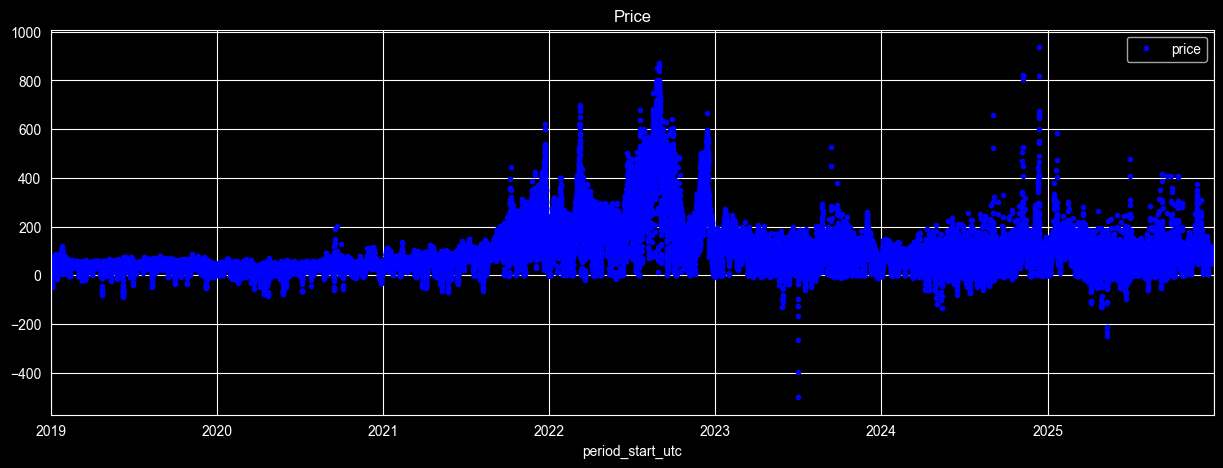

In [498]:
df_years.plot( y='price', style='.', figsize=(15, 5), color='blue', title='Price')
plt.show()

# Train / Test Split

In [499]:
start_date = pd.to_datetime('2024-01-01 00:00:00')# + relativedelta(days=8)
split_date = pd.to_datetime('2025-02-01 00:00:00')
# end_date = pd.to_datetime('2026-01-01 00:00:00')
end_date = split_date + relativedelta(days=1)

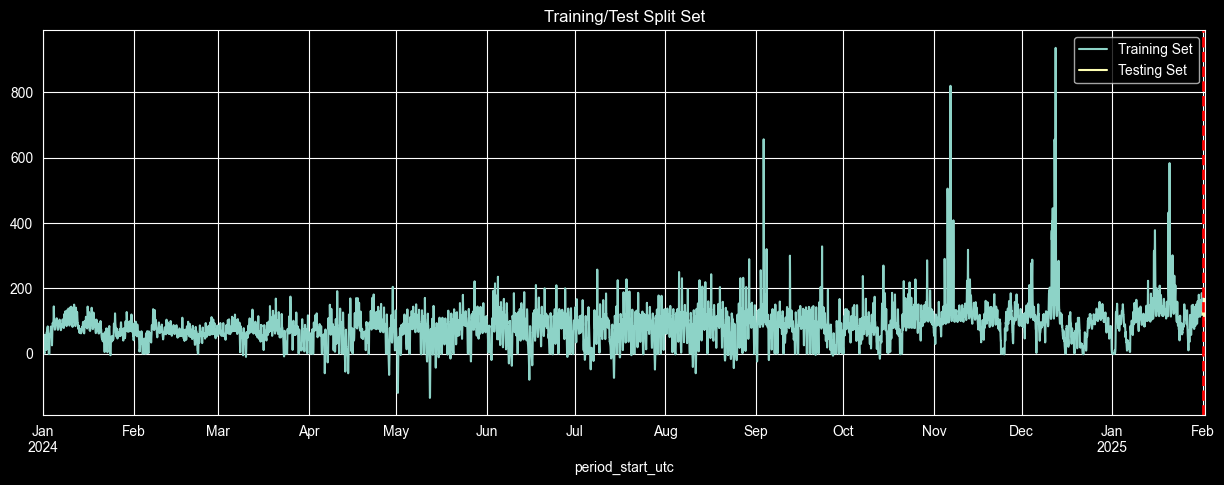

In [500]:
train = df_years.query('@start_date <= date < @split_date')
test = df_years.query('@split_date <= date < @end_date')

#train = df_years.query('date < 2021')
#test = df_years.query('2021 <= date < "2021-07"')

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(y='price', ax=ax, label='Training Set', title='Training/Test Split Set')
test.plot(y='price', ax=ax, label = 'Testing Set')
ax.axvline(split_date, color='red', linestyle='dashed', linewidth=2)
plt.legend()
plt.show()

# Feature Creation

In [501]:
df_years.index

DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00', '2019-01-01 03:00:00',
               '2019-01-01 04:00:00', '2019-01-01 05:00:00',
               '2019-01-01 06:00:00', '2019-01-01 07:00:00',
               '2019-01-01 08:00:00', '2019-01-01 09:00:00',
               ...
               '2025-12-31 13:00:00', '2025-12-31 14:00:00',
               '2025-12-31 15:00:00', '2025-12-31 16:00:00',
               '2025-12-31 17:00:00', '2025-12-31 18:00:00',
               '2025-12-31 19:00:00', '2025-12-31 20:00:00',
               '2025-12-31 21:00:00', '2025-12-31 22:00:00'],
              dtype='datetime64[ns]', name='period_start_utc', length=61367, freq=None)

In [502]:
def create_features(df):
    """
    create time series features based on time series index
    :param df:
    :return:
    """
    df = df.copy()

    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['weekday'] = df.index.weekday
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df

Text(0.5, 1.0, 'Price by Hour')

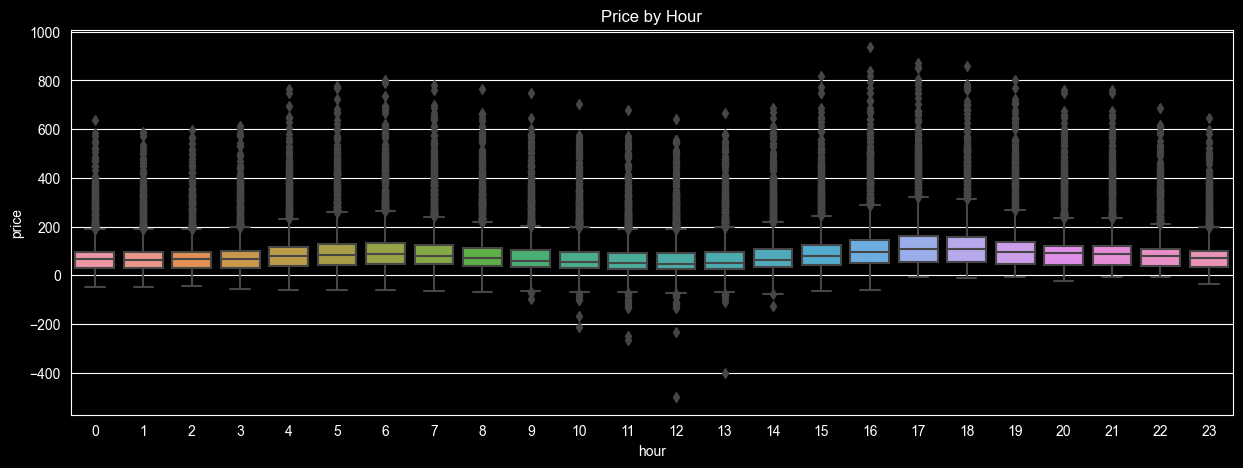

In [503]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data = df_years, x = 'hour', y= 'price')
ax.set_title('Price by Hour')

Text(0.5, 1.0, 'Price by Month')

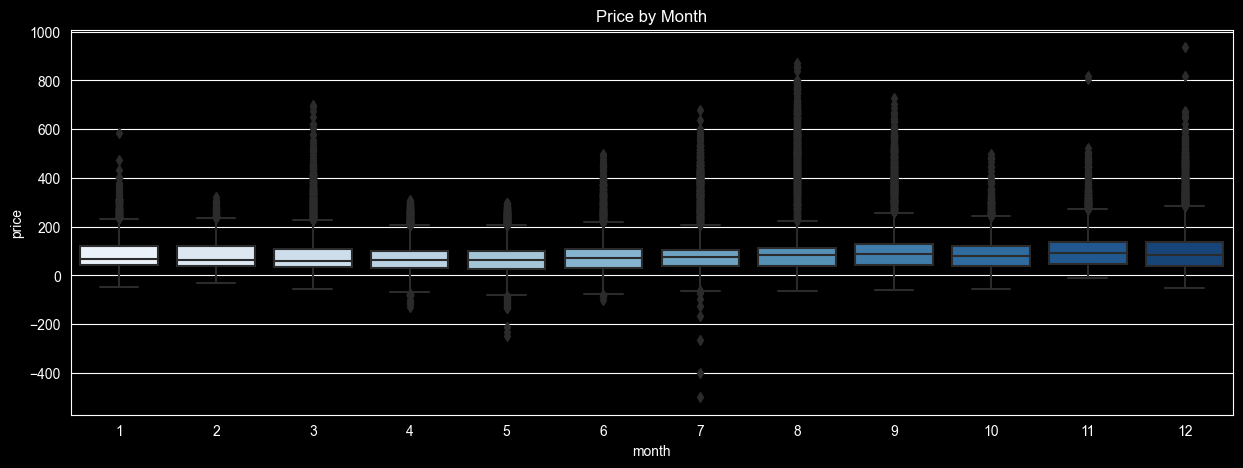

In [504]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data = df_years, x = 'month', y= 'price', palette='Blues')
ax.set_title('Price by Month')

# Create Model

In [505]:
df_years.columns

Index(['date', 'month', 'day', 'dayofyear', 'hour', 'dayofweek', 'price',
       'load_forecast_da', 'off_wind_da', 'on_wind_da', 'solar_da',
       'gen_forecast_da', 'res_sum_da', 'dayofyear_sin1', 'dayofyear_cos1',
       'hour_sin1', 'hour_cos1', 'dayofweek_sin1', 'dayofweek_cos1',
       'is_holiday', 'day_type', 'price_gas', 'year_2020', 'year_2021',
       'year_2022', 'year_2023', 'year_2024', 'year_2025'],
      dtype='object')

In [506]:
#FEATURES = ['year', 'month', 'day', 'dayofyear', 'hour', 'week', 'dayofweek', 'load_forecast_da', 'res_sum_da', 'dayofyear_sin1',
#       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
#       'dayofweek_cos1', 'is_holiday', 'price_gas']
FEATURES = ['load_forecast_da', 'res_sum_da', 'gen_forecast_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'price_gas', 'year_2020', 'year_2021', 'year_2022',
       'year_2023', 'year_2024', 'year_2025']
#FEATURES = ['year', 'price_gas', 'res_sum_da', 'load_forecast_da']
TARGET = 'price'

In [507]:
reg = xgb_model.create_and_train_XGBoost(train, test, FEATURES, TARGET)

[0]	validation_0-rmse:96.79290
[50]	validation_0-rmse:62.50055
[100]	validation_0-rmse:41.99253
[150]	validation_0-rmse:29.84090
[200]	validation_0-rmse:22.96009


C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [17:25:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "enable_categorial" } are not used.

  self.starting_round = model.num_boosted_rounds()


[250]	validation_0-rmse:19.06333
[300]	validation_0-rmse:16.73800
[350]	validation_0-rmse:15.28074
[400]	validation_0-rmse:14.27097
[450]	validation_0-rmse:13.51810
[500]	validation_0-rmse:12.91580
[550]	validation_0-rmse:12.45917
[600]	validation_0-rmse:12.08128
[650]	validation_0-rmse:11.73666
[700]	validation_0-rmse:11.47717
[750]	validation_0-rmse:11.25282
[800]	validation_0-rmse:11.04195
[850]	validation_0-rmse:10.84725
[900]	validation_0-rmse:10.62596
[950]	validation_0-rmse:10.43000
[1000]	validation_0-rmse:10.26724
[1050]	validation_0-rmse:10.09134
[1100]	validation_0-rmse:9.94860
[1150]	validation_0-rmse:9.78728
[1200]	validation_0-rmse:9.63392
[1250]	validation_0-rmse:9.50039
[1300]	validation_0-rmse:9.36020
[1350]	validation_0-rmse:9.23206
[1400]	validation_0-rmse:9.09761
[1450]	validation_0-rmse:8.98020
[1499]	validation_0-rmse:8.87416


In [508]:
#reg.score()

# Feature Importance

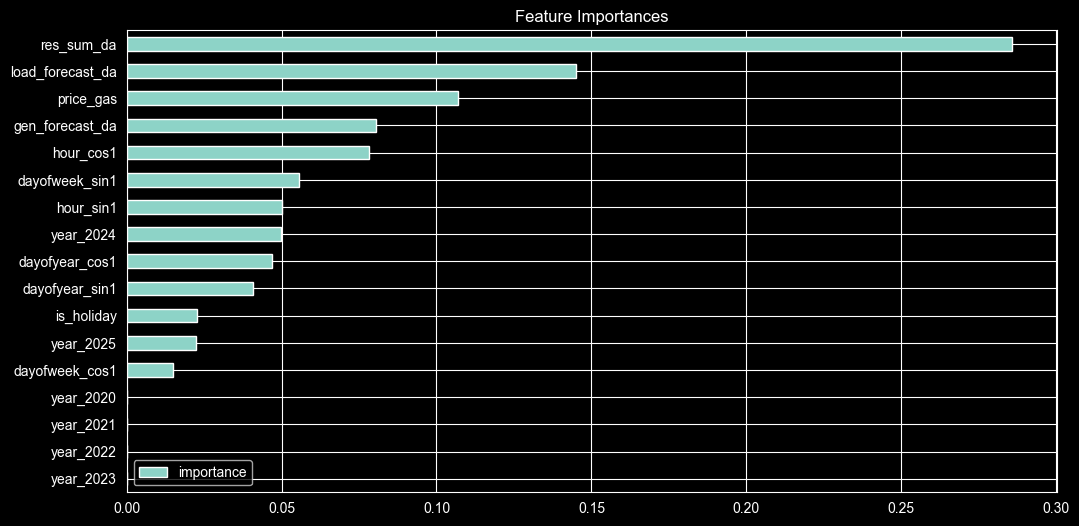

In [509]:
xgb_model.display_feature_importance(reg)

# Forecast on Test

In [510]:
y_pred = reg.predict(test[FEATURES])
rmse = root_mean_squared_error(test[TARGET], y_pred)
print(f'RMSE: {rmse}')
mae = mean_absolute_error(test[TARGET], y_pred)
print(f'MAE Grid Search: {mae}')

RMSE: 12.44475799415968
MAE Grid Search: 11.046988716125488


In [511]:
test['prediction'] = reg.predict(test[FEATURES])

C:\Users\bened\AppData\Local\Temp\ipykernel_35220\677415749.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = reg.predict(test[FEATURES])


In [512]:
df_years = df_years.merge(test[['prediction']],  how = 'left', left_index=True, right_index=True) # merge on index columns

In [513]:
df_years

,date,month,day,dayofyear,hour,dayofweek,price,load_forecast_da,off_wind_da,on_wind_da,...,is_holiday,day_type,price_gas,year_2020,year_2021,year_2022,year_2023,year_2024,year_2025,prediction
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,2019-01-01,1,1,1,0,1,10.0700,41692.5650,5042.4425,20626.5625,...,1,holiday,22.280,False,False,False,False,False,False,NaN
2019-01-01 01:00:00,2019-01-01,1,1,1,1,1,-4.0800,40587.2325,5028.4175,22355.6850,...,1,holiday,22.280,False,False,False,False,False,False,NaN
2019-01-01 02:00:00,2019-01-01,1,1,1,2,1,-9.9100,40308.2500,4977.6500,24032.4775,...,1,holiday,22.280,False,False,False,False,False,False,NaN
2019-01-01 03:00:00,2019-01-01,1,1,1,3,1,-7.4100,40659.5750,4907.4000,25452.1675,...,1,holiday,22.280,False,False,False,False,False,False,NaN
2019-01-01 04:00:00,2019-01-01,1,1,1,4,1,-12.5500,40947.7300,4882.8400,26526.3700,...,1,holiday,22.280,False,False,False,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 18:00:00,2025-12-31,12,31,365,18,2,95.9900,61429.2525,5430.0475,25289.8075,...,0,weekday,27.755,False,False,False,False,False,True,NaN
2025-12-31 19:00:00,2025-12-31,12,31,365,19,2,86.8025,58695.5025,5494.9900,26179.9500,...,0,weekday,27.755,False,False,False,False,False,True,NaN
2025-12-31 20:00:00,2025-12-31,12,31,365,20,2,79.7975,55991.9725,5359.1000,27294.2850,...,0,weekday,27.755,False,False,False,False,False,True,NaN


In [514]:
df_years.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61367 entries, 2019-01-01 00:00:00 to 2025-12-31 22:00:00
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              61367 non-null  datetime64[ns]
 1   month             61367 non-null  int64         
 2   day               61367 non-null  int64         
 3   dayofyear         61367 non-null  int64         
 4   hour              61367 non-null  int64         
 5   dayofweek         61367 non-null  int64         
 6   price             61367 non-null  float64       
 7   load_forecast_da  61367 non-null  float64       
 8   off_wind_da       61367 non-null  float64       
 9   on_wind_da        61367 non-null  float64       
 10  solar_da          61367 non-null  float64       
 11  gen_forecast_da   61367 non-null  float64       
 12  res_sum_da        61367 non-null  float64       
 13  dayofyear_sin1    61367 non-null  float64

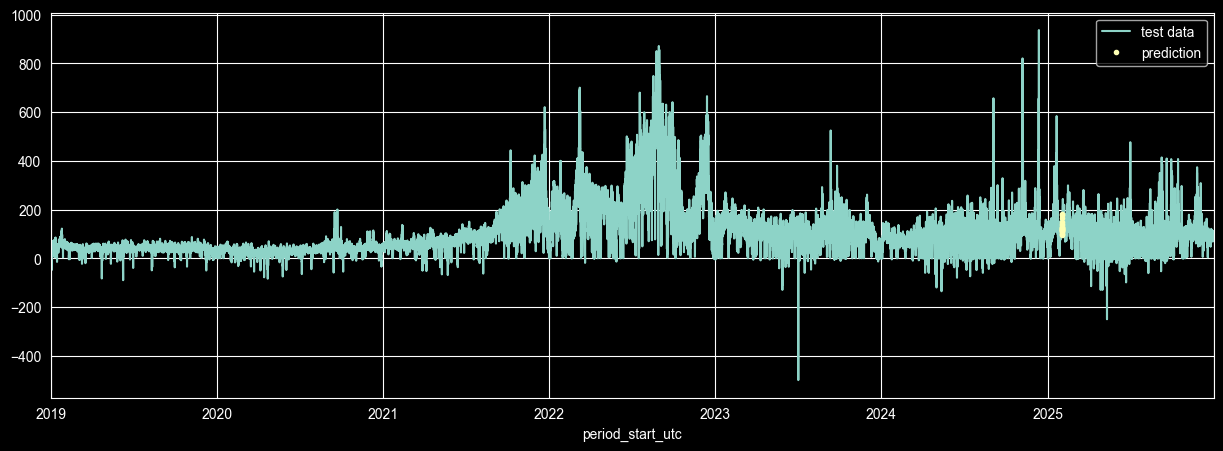

Text(0.5, 1.0, 'Test Data and Predictions')

In [515]:
ax = df_years[['price']].plot(figsize=(15, 5))
df_years['prediction'].plot(ax=ax, style = '.')
plt.legend(['test data', 'prediction'])
plt.show()
ax.set_title('Test Data and Predictions')

# smaller test frames

In [516]:
add_three_months = relativedelta(months=3)
add_one_week = relativedelta(days=7)

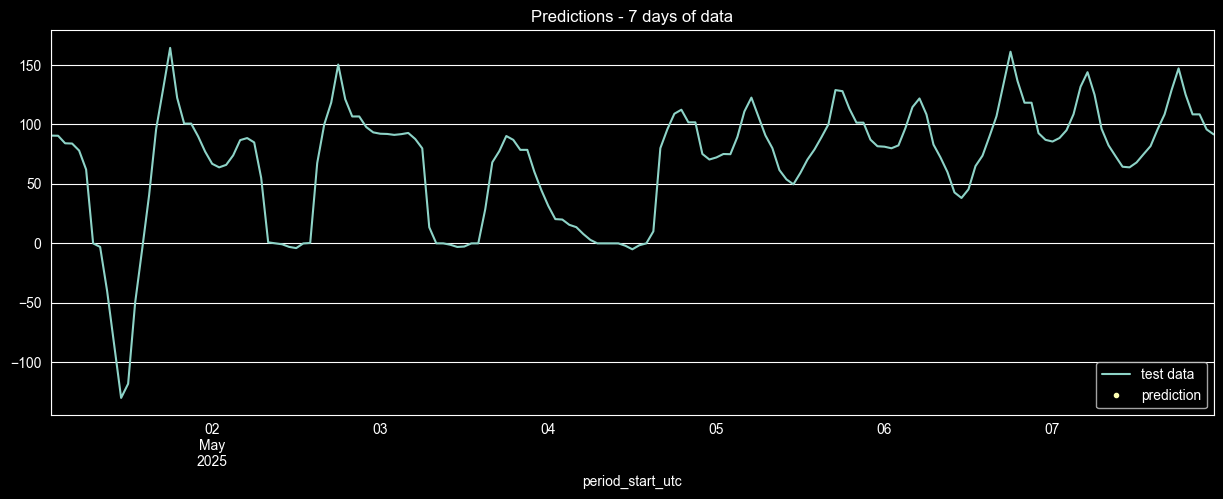

In [517]:
first_day_four_months_in = split_date + add_three_months
first_day_four_months_in.to_datetime64()
last_day_four_months_in = first_day_four_months_in + add_one_week
last_day_four_months_in.to_datetime64()

ax = df_years.loc[(first_day_four_months_in < df_years.index) & (df_years.index < last_day_four_months_in)]['price'].plot(figsize=(15, 5), title='Predictions - 7 days of data')
df_years.loc[(first_day_four_months_in < df_years.index) & (df_years.index < last_day_four_months_in)]['prediction'].plot(ax=ax, style='.')
plt.legend(['test data', 'prediction'])
plt.show()

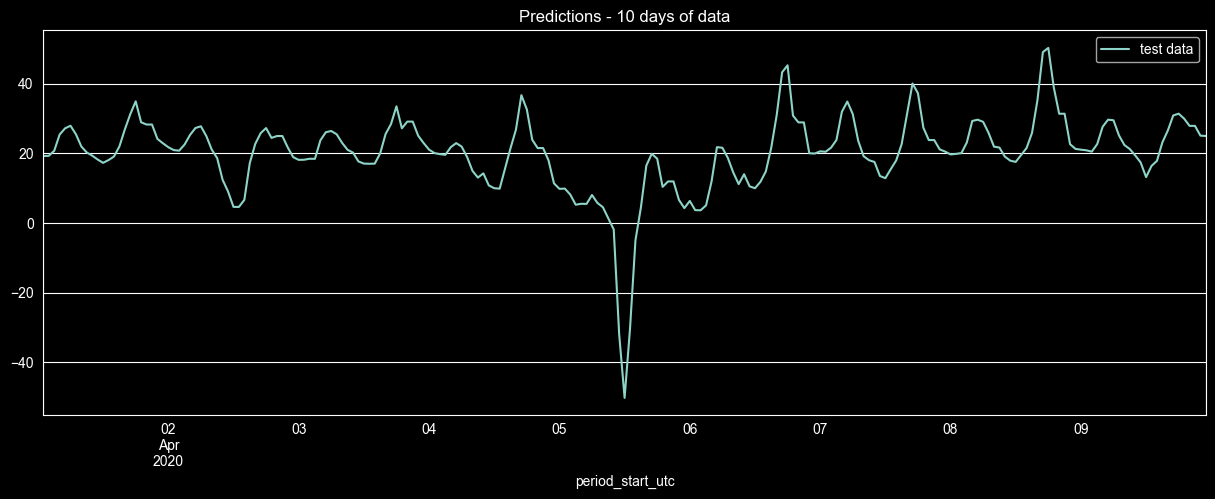

In [518]:
ax = df_years.loc[("2020-04-01" < df_years.index) & (df_years.index < "2020-04-10")]['price'].plot(figsize=(15, 5), title='Predictions - 10 days of data')
plt.legend(['test data'])
plt.show()

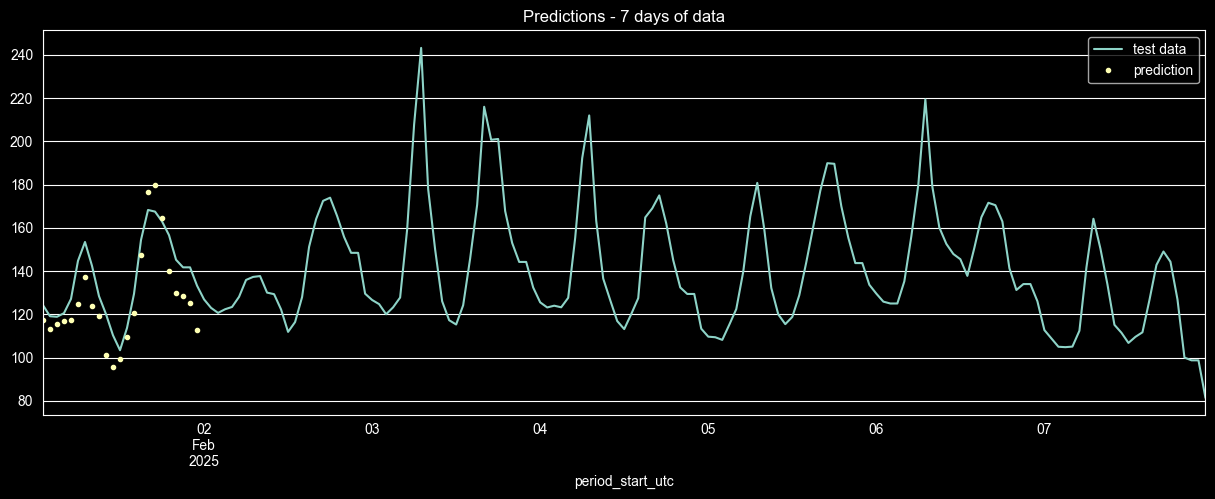

In [519]:
split_date_one_week_in = split_date + add_one_week

ax = df_years.loc[(split_date < df_years.index) & (df_years.index < split_date_one_week_in)]['price'].plot(figsize=(15, 5), title='Predictions - 7 days of data')
df_years.loc[(split_date < df_years.index) & (df_years.index < split_date_one_week_in)]['prediction'].plot(ax=ax, style='.')
plt.legend(['test data', 'prediction'])
plt.show()

# Using Grid/Randomizer Search

In [520]:
# Define the hyperparameter distributions
param_grid_simple = {
    'base_score':[0.5],
    'max_depth': np.arange(4, 7, 1).tolist(),
    'learning_rate': np.arange(0.01, 0.2, 0.1).tolist(),
    'subsample': [0.8],
    'n_estimators': np.arange(1100, 1500, 200).tolist(),
    'colsample_bytree': [0.8],
    'objective':['reg:squarederror'],
}

In [521]:
# Define the hyperparameter distributions
param_grid = {
    'base_score':[0.5],
    'max_depth': np.arange(3, 8, 1).tolist(),
    'learning_rate': np.arange(0.01, 0.2, 0.03).tolist(),
    'subsample': [0.8],
    'n_estimators': np.arange(1000, 2000, 200).tolist(),
    'colsample_bytree': np.arange(0.7, 0.9, 0.1).tolist(),
    'objective':['reg:squarederror'],
}

In [522]:
best_grid_search_model = xgb_model.paramater_search_XGBoost(train, FEATURES, TARGET, 'grid', param_grid_simple)

Best set of hyperparameters:  {'base_score': 0.5, 'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 1300, 'objective': 'reg:squarederror', 'subsample': 0.8}
Best score:  -26.919116361502518


In [523]:
y_pred_grid_search = best_grid_search_model.predict(test[FEATURES])
rmse_grid_search = root_mean_squared_error(test[TARGET], y_pred_grid_search)
print(f'RMSE Grid Search: {rmse_grid_search}')
mae_grid_search = mean_absolute_error(test[TARGET], y_pred_grid_search)
print(f'MAE Grid Search: {mae_grid_search}')

RMSE Grid Search: 12.595520459060563
MAE Grid Search: 11.244208882649739


In [524]:
test['prediction_grid_search'] = y_pred_grid_search
df_years = df_years.merge(test[['prediction_grid_search']],  how = 'left', left_index=True, right_index=True) # merge on index columns

C:\Users\bened\AppData\Local\Temp\ipykernel_35220\3407822560.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction_grid_search'] = y_pred_grid_search


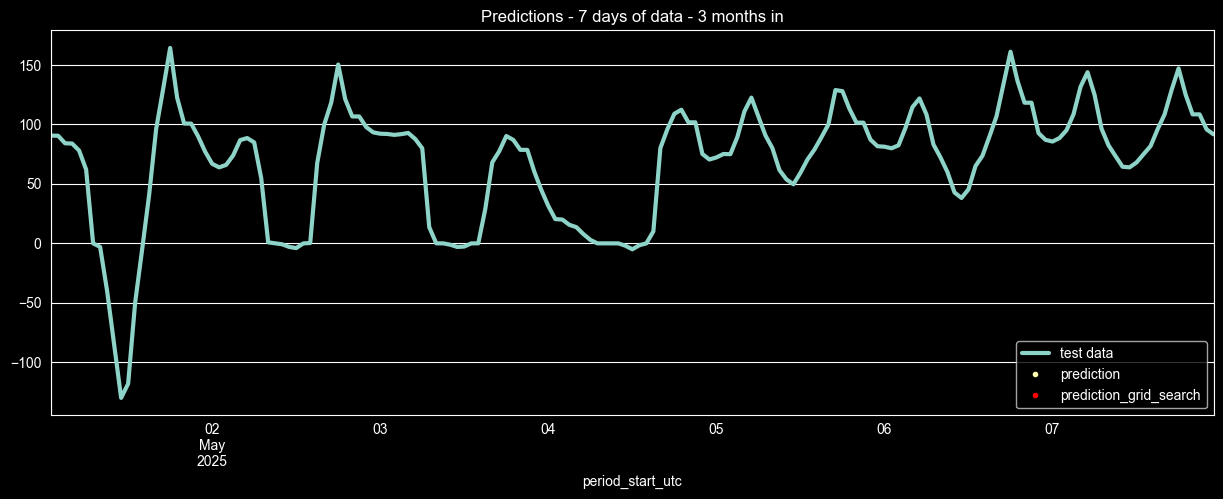

In [525]:
ax = df_years.loc[(first_day_four_months_in < df_years.index) & (df_years.index < last_day_four_months_in)]['price'].plot(figsize=(15, 5), linewidth=3, title='Predictions - 7 days of data - 3 months in')
df_years.loc[(first_day_four_months_in < df_years.index) & (df_years.index < last_day_four_months_in)]['prediction'].plot(ax=ax, style='.')
df_years.loc[(first_day_four_months_in < df_years.index) & (df_years.index < last_day_four_months_in)]['prediction_grid_search'].plot(ax=ax, style='.', color='red')
plt.legend(['test data', 'prediction', 'prediction_grid_search'])
plt.show()

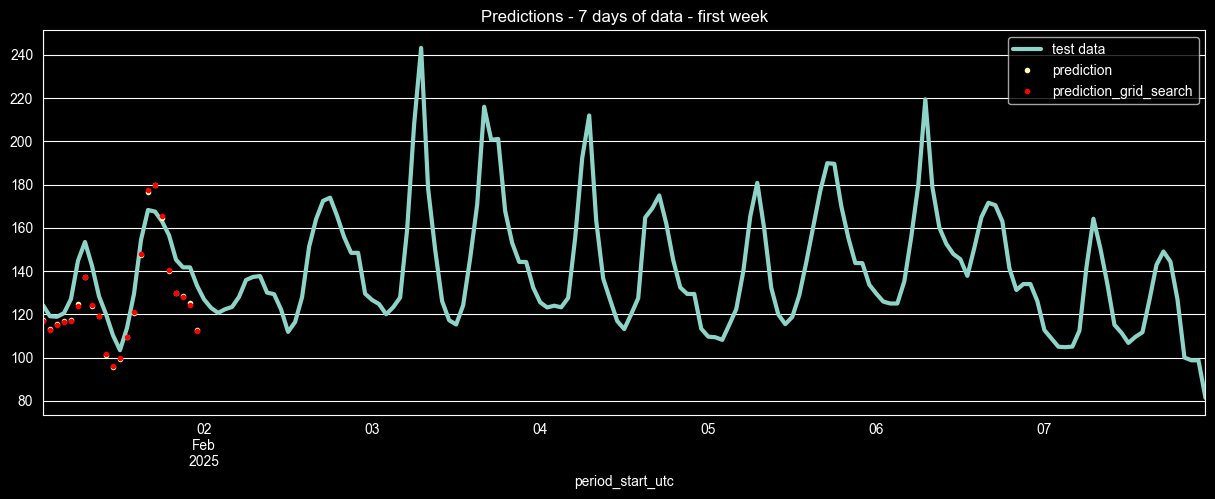

In [526]:
ax = df_years.loc[(split_date < df_years.index) & (df_years.index < split_date_one_week_in)]['price'].plot(figsize=(15, 5), linewidth=3, title='Predictions - 7 days of data - first week')
df_years.loc[(split_date < df_years.index) & (df_years.index < split_date_one_week_in)]['prediction'].plot(ax=ax, style='.')
df_years.loc[(split_date < df_years.index) & (df_years.index < split_date_one_week_in)]['prediction_grid_search'].plot(ax=ax, style='.', color='red')
plt.legend(['test data', 'prediction', 'prediction_grid_search'])
plt.show()

In [527]:
print(f'RMSE: {round(rmse, 2)} EUR/MWh')
print(f'RMSE Grid Search: {round(rmse_grid_search, 2)} EUR/MWh')
print(f'MAE: {round(mae, 2)} EUR/MWh')
print(f'MAE Grid Search: {round(mae_grid_search, 2)} EUR/MWh')

RMSE: 12.44 EUR/MWh
RMSE Grid Search: 12.6 EUR/MWh
MAE: 11.05 EUR/MWh
MAE Grid Search: 11.24 EUR/MWh


In [528]:
# Define the hyperparameter distributions
param_dist = {
    'base_score':stats.uniform(0.3, 0.7),
    'max_depth': stats.randint(3, 10),
    'learning_rate': stats.uniform(0.001, 0.2),
    'subsample': stats.uniform(0.5, 0.9),
    'n_estimators':stats.randint(200, 2000),
    'colsample_bytree':stats.uniform(0.5, 0.8)
}

In [529]:
#xgb_model.paramater_search_XGBoost(train, FEATURES, TARGET, 'random', param_dist)

# Lagging

In [530]:
df_lag = df_years.copy()
df_lag[f'gas_price_lag_1days'] = df_lag['price_gas'].shift(periods=1*24)
df_lag[f'gas_price_lag_2days'] = df_lag['price_gas'].shift(periods=2*24)
df_lag[f'gas_price_lag_3days'] = df_lag['price_gas'].shift(periods=3*24)
df_lag[f'gas_price_lag_4days'] = df_lag['price_gas'].shift(periods=4*24)
df_lag[f'gas_price_lag_5days'] = df_lag['price_gas'].shift(periods=5*24)
df_lag[f'gas_price_lag_6days'] = df_lag['price_gas'].shift(periods=6*24)
df_lag[f'gas_price_lag_7days'] = df_lag['price_gas'].shift(periods=7*24)
df_lag.head()

,date,month,day,dayofyear,hour,dayofweek,price,load_forecast_da,off_wind_da,on_wind_da,...,year_2025,prediction,prediction_grid_search,gas_price_lag_1days,gas_price_lag_2days,gas_price_lag_3days,gas_price_lag_4days,gas_price_lag_5days,gas_price_lag_6days,gas_price_lag_7days
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,2019-01-01,1,1,1,0,1,10.07,41692.5650,5042.4425,20626.5625,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00,2019-01-01,1,1,1,1,1,-4.08,40587.2325,5028.4175,22355.6850,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00,2019-01-01,1,1,1,2,1,-9.91,40308.2500,4977.6500,24032.4775,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00,2019-01-01,1,1,1,3,1,-7.41,40659.5750,4907.4000,25452.1675,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00,2019-01-01,1,1,1,4,1,-12.55,40947.7300,4882.8400,26526.3700,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [531]:
start_date_lag = start_date + relativedelta(days=8)
train_lag = df_lag.query('@start_date <= date < @split_date')
test_lag = df_lag.query('@split_date <= date < @end_date')

In [532]:
FEATURES_lag_3days = ['load_forecast_da', 'res_sum_da', 'gen_forecast_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'year_2020', 'year_2021', 'year_2022',
       'year_2023', 'year_2024', 'year_2025', 'gas_price_lag_1days', 'gas_price_lag_2days',	'gas_price_lag_3days']
#FEATURES = ['year', 'price_gas', 'res_sum_da', 'load_forecast_da']
TARGET = 'price'

In [533]:
reg_lag_3days = xgb_model.create_and_train_XGBoost(train_lag, test_lag, FEATURES_lag_3days, TARGET)

[0]	validation_0-rmse:96.82537
[50]	validation_0-rmse:62.41746
[100]	validation_0-rmse:41.92075
[150]	validation_0-rmse:29.65261


C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [17:26:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "enable_categorial" } are not used.

  self.starting_round = model.num_boosted_rounds()


[200]	validation_0-rmse:22.64696
[250]	validation_0-rmse:18.67523
[300]	validation_0-rmse:16.32173
[350]	validation_0-rmse:14.88311
[400]	validation_0-rmse:13.88952
[450]	validation_0-rmse:13.16688
[500]	validation_0-rmse:12.63864
[550]	validation_0-rmse:12.22326
[600]	validation_0-rmse:11.86689
[650]	validation_0-rmse:11.53078
[700]	validation_0-rmse:11.28909
[750]	validation_0-rmse:11.07672
[800]	validation_0-rmse:10.85983
[850]	validation_0-rmse:10.66771
[900]	validation_0-rmse:10.45884
[950]	validation_0-rmse:10.28458
[1000]	validation_0-rmse:10.11665
[1050]	validation_0-rmse:9.95252
[1100]	validation_0-rmse:9.79751
[1150]	validation_0-rmse:9.64581
[1200]	validation_0-rmse:9.50634
[1250]	validation_0-rmse:9.37514
[1300]	validation_0-rmse:9.24690
[1350]	validation_0-rmse:9.12518
[1400]	validation_0-rmse:9.00780
[1450]	validation_0-rmse:8.88761
[1499]	validation_0-rmse:8.78597


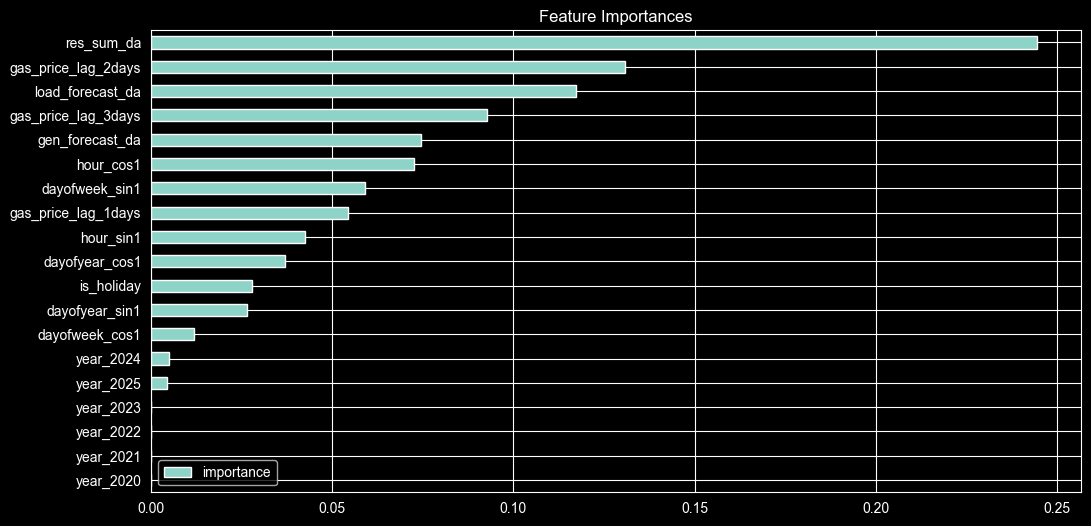

In [534]:
xgb_model.display_feature_importance(reg_lag_3days)

In [535]:
y_pred_lag_3days = reg_lag_3days.predict(test_lag[FEATURES_lag_3days])
rmse_lag_3days = root_mean_squared_error(test_lag[TARGET], y_pred_lag_3days)
print(f'RMSE lag 3 days: {round(rmse_lag_3days, 2)} EUR/MWh')
mae_lag_3days = mean_absolute_error(test_lag[TARGET], y_pred_lag_3days)
print(f'MAE lag 3 days: {round(rmse_lag_3days, 2)} EUR/MWh')

RMSE lag 3 days: 10.77 EUR/MWh
MAE lag 3 days: 10.77 EUR/MWh


In [536]:
FEATURES_lag_7days = ['load_forecast_da', 'res_sum_da', 'gen_forecast_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'year_2020', 'year_2021', 'year_2022',
       'year_2023', 'year_2024', 'year_2025', 'gas_price_lag_1days', 'gas_price_lag_2days',	'gas_price_lag_3days', 'gas_price_lag_4days', 'gas_price_lag_5days', 'gas_price_lag_6days', 'gas_price_lag_7days']
#FEATURES = ['year', 'price_gas', 'res_sum_da', 'load_forecast_da']
TARGET = 'price'

In [537]:
reg_lag_7days = xgb_model.create_and_train_XGBoost(train_lag, test_lag, FEATURES_lag_7days, TARGET)

[0]	validation_0-rmse:96.79343
[50]	validation_0-rmse:62.50312
[100]	validation_0-rmse:41.86896
[150]	validation_0-rmse:29.62312


C:\Users\bened\Documents\neuefische\capstone-project\ai-for-energy\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [17:26:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "enable_categorial" } are not used.

  self.starting_round = model.num_boosted_rounds()


[200]	validation_0-rmse:22.60061
[250]	validation_0-rmse:18.60528
[300]	validation_0-rmse:16.21913
[350]	validation_0-rmse:14.69182
[400]	validation_0-rmse:13.73524
[450]	validation_0-rmse:12.99984
[500]	validation_0-rmse:12.45078
[550]	validation_0-rmse:11.99948
[600]	validation_0-rmse:11.64464
[650]	validation_0-rmse:11.32586
[700]	validation_0-rmse:11.08146
[750]	validation_0-rmse:10.84825
[800]	validation_0-rmse:10.60900
[850]	validation_0-rmse:10.42885
[900]	validation_0-rmse:10.24067
[950]	validation_0-rmse:10.07263
[1000]	validation_0-rmse:9.88575
[1050]	validation_0-rmse:9.72886
[1100]	validation_0-rmse:9.59708
[1150]	validation_0-rmse:9.44427
[1200]	validation_0-rmse:9.30724
[1250]	validation_0-rmse:9.18009
[1300]	validation_0-rmse:9.04341
[1350]	validation_0-rmse:8.92515
[1400]	validation_0-rmse:8.80535
[1450]	validation_0-rmse:8.68248
[1499]	validation_0-rmse:8.56907


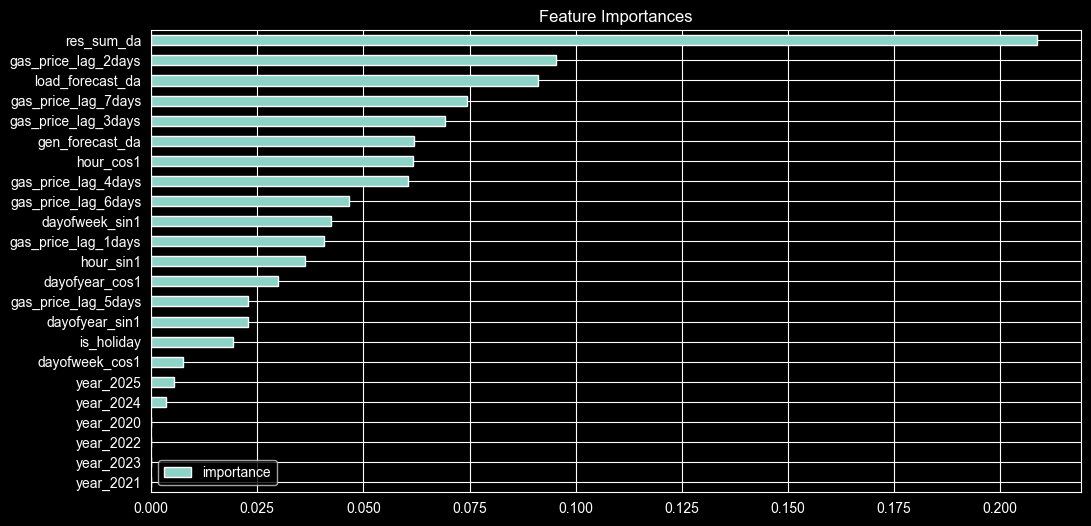

In [538]:
xgb_model.display_feature_importance(reg_lag_7days)

In [539]:
y_pred_lag_7days = reg_lag_7days.predict(test_lag[FEATURES_lag_7days])
rmse_lag_7days = root_mean_squared_error(test_lag[TARGET], y_pred_lag_7days)
print(f'RMSE lag 7 days: {round(rmse_lag_7days, 2)} EUR/MWh')
mae_lag_7days = mean_absolute_error(test_lag[TARGET], y_pred_lag_7days)
print(f'MAE lag 7 days: {round(rmse_lag_7days, 2)} EUR/MWh')

RMSE lag 7 days: 12.63 EUR/MWh
MAE lag 7 days: 12.63 EUR/MWh


In [540]:
print(f'RMSE: {round(rmse, 2)} EUR/MWh')
print(f'RMSE Grid Search: {round(rmse_grid_search, 2)} EUR/MWh')
print(f'RMSE lag 3 days: {round(rmse_lag_3days, 2)} EUR/MWh')
print(f'RMSE lag 7 days: {round(rmse_lag_7days, 2)} EUR/MWh')
print(f'MAE: {round(mae, 2)} EUR/MWh')
print(f'MAE Grid Search: {round(mae_grid_search, 2)} EUR/MWh')
print(f'MAE lag 3 days: {round(mae_lag_3days, 2)} EUR/MWh')
print(f'MAE lag 7 days: {round(mae_lag_7days, 2)} EUR/MWh')

RMSE: 12.44 EUR/MWh
RMSE Grid Search: 12.6 EUR/MWh
RMSE lag 3 days: 10.77 EUR/MWh
RMSE lag 7 days: 12.63 EUR/MWh
MAE: 11.05 EUR/MWh
MAE Grid Search: 11.24 EUR/MWh
MAE lag 3 days: 9.15 EUR/MWh
MAE lag 7 days: 10.31 EUR/MWh


In [541]:
results = {
    'Algorithm': ['XGBoost', '... with GridSearch', '... with 3 days gas price lag', '... with 7 days gas price lag'],
    'RMSE in EUR/MWh': [round(rmse, 2), round(rmse_grid_search, 2), round(rmse_lag_3days, 2), round(rmse_lag_7days, 2)],
    'MAE in EUR/MWh': [round(mae, 2), round(mae_grid_search, 2), round(mae_lag_3days, 2), round(mae_lag_7days, 2)]
}
results_frame = pd.DataFrame(data=results)
results_frame

,Algorithm,RMSE in EUR/MWh,MAE in EUR/MWh
0,XGBoost,12.44,11.05
1,... with GridSearch,12.60,11.24
2,... with 3 days gas price lag,10.77,9.15
3,... with 7 days gas price lag,12.63,10.31
